In [29]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

use september
use hourly, with start 2025-09-01  01:00:00
convert to wintertime
convert from l/h to m^3/s 
monthly estimate of concentration = 55 000 000 MPN/100ml

In [3]:
filename = Path(r"C:/Users/karoa/MOHID_internship/MOHID_model_workflow/data/preprocessing/Caudales_PSJ_2025.xlsx")
output_folder = filename.parent

df = pd.read_excel(
    filename,
    sheet_name='Septiembre',
    usecols=['Fecha', 'Caudal salida general (l/h)']
)


In [4]:
df['datetime'] = pd.to_datetime(df['Fecha']) - pd.Timedelta(hours=1) # converting to wintertime
df['flow (m3/s)'] = df['Caudal salida general (l/h)'] / (3600000)
# --- Build the SECONDS column relative to the first timestamp ---
t0 = df['datetime'].iloc[0]
df['seconds'] = (df['datetime'] - t0).dt.total_seconds().astype(int)

# ---  Write the output file ---
# build fileout name
start = df['datetime'].iloc[0]
end = df['datetime'].iloc[-1]

fileout = output_folder / f"discharge_{start.year}_{start.month}_{start.day}_{end.year}_{end.month}_{end.day}.dat"
#fileout = f'WIND_{start.year}_{start.month}_{start.day}_{end.year}_{end.month}_{end.day}.dat'

initial = t0.strftime('%Y. %m. %d. %H. %M. %S.').replace(' 0', ' ')  
# Safer: build the header explicitly from the datetime parts
initial = f"{t0.year}. {t0.month:>2}. {t0.day:>2}. {t0.hour}. {t0.minute}. {t0.second}."


In [5]:
with open(fileout, 'w') as f:
    f.write("TIME_UNITS                : SECONDS\n")
    f.write(f"SERIE_INITIAL_DATA        : {initial}\n")
    f.write("\n")
    f.write("SECONDS                   flow (m3/s)\n")
    f.write("<BeginTimeSerie>\n")
    for _, row in df.iterrows():
        # Skip rows where either component is NaN (from the -9999.9 fill values)
        if pd.isna(row['flow (m3/s)']):
            continue
        f.write(f"{row['seconds']}                           "
                f"{row['flow (m3/s)']:.10g}\n")
    f.write("<EndTimeSerie>\n")

In [9]:
df.head()

,Fecha,Caudal salida general (l/h),datetime,flow (m3/s),seconds
0,2025-09-01 01:00:00,10665.990021,2025-09-01 00:00:00,0.002963,0
1,2025-09-01 02:15:00,5620.894484,2025-09-01 01:15:00,0.001561,4500
2,2025-09-01 03:30:00,10917.330831,2025-09-01 02:30:00,0.003033,9000
3,2025-09-01 04:45:00,15231.253101,2025-09-01 03:45:00,0.004231,13500
4,2025-09-01 06:00:00,5620.894484,2025-09-01 05:00:00,0.001561,18000


In [56]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

C:\Users\karoa\AppData\Local\Temp\ipykernel_3804\535364290.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


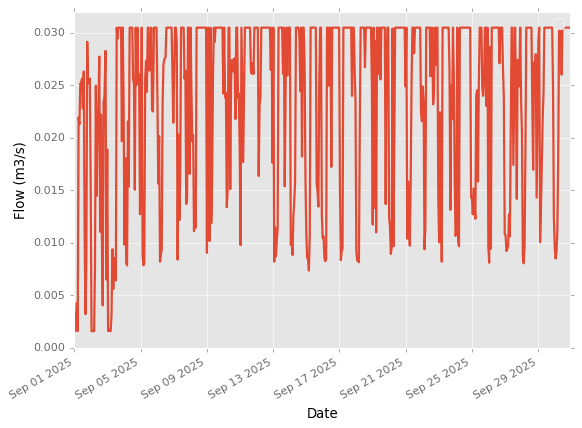

In [65]:
plt.style.use('ggplot')
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'black'
df.plot('datetime', 'flow (m3/s)', label='')
plt.ylim(0,0.032)
plt.xlabel('Date')
plt.ylabel('Flow (m3/s)')
plt.legend()
plt.show()
